In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ─── Global Plot Style ─────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_palette('Set2')

# AQI colour mapping (used throughout)
AQI_COLORS = {
    'Good': '#2ecc71',
    'Satisfactory': '#a8e063',
    'Moderate': '#f39c12',
    'Poor': '#e67e22',
    'Very Poor': '#e74c3c',
    'Severe': '#8e44ad'
}
AQI_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ── UPDATE this path to where you saved the file in your Drive ──────────────
FILE_PATH = '/content/drive/MyDrive/Project_ National Air Quality.xlsx'

df_raw = pd.read_excel(FILE_PATH, parse_dates=['Date'])

print(f"Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(10)

Dataset loaded: 27 rows × 13 columns


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket
0,Bengaluru,2016-08-31,35.17,51.69,3.61,19.08,2.06,40.41,0.41,3.70,20.34,49.0,Good
1,Bengaluru,2016-09-01,37.57,46.28,4.82,22.32,2.61,40.49,0.46,3.72,21.40,57.0,Satisfactory
2,Bengaluru,2017-01-13,31.22,108.09,4.05,26.86,NaN,26.04,0.55,3.67,50.80,91.0,Satisfactory
3,Bengaluru,2017-01-14,29.21,NaN,2.03,13.26,NaN,24.76,0.00,3.29,63.14,78.0,Satisfactory
4,Bengaluru,2017-07-07,NaN,126.74,15.39,27.96,NaN,NaN,0.56,3.86,12.39,NaN,NaN
5,Delhi,2015-10-28,113.18,254.24,32.12,43.78,74.53,22.81,2.08,18.61,71.98,333.0,Very Poor
6,Delhi,2015-10-29,93.86,183.08,25.74,57.74,77.86,25.55,1.90,24.29,73.26,262.0,Poor
7,Delhi,2015-10-30,106.16,156.58,24.98,42.63,55.71,28.72,2.07,18.92,60.56,233.0,Poor
8,Delhi,2015-10-31,245.97,274.06,36.55,35.11,58.72,35.77,1.78,17.66,42.32,340.0,Very Poor
9,Delhi,2015-11-01,270.96,379.38,60.39,60.17,94.74,51.64,2.52,28.58,84.99,415.0,Severe


In [4]:
print("=" * 55)
print(" DATASET BASIC INFORMATION")
print("=" * 55)
print(f"  Shape          : {df_raw.shape}")
print(f"  Cities         : {df_raw['City'].nunique()} → {df_raw['City'].unique().tolist()}")
print(f"  Date Range     : {df_raw['Date'].min().date()} to {df_raw['Date'].max().date()}")
print(f"  AQI Buckets    : {df_raw['AQI_Bucket'].dropna().unique().tolist()}")
print("="*55)
df_raw.info()

 DATASET BASIC INFORMATION
  Shape          : (27, 13)
  Cities         : 5 → ['Bengaluru', 'Delhi', 'Gurugram', 'Hyderabad', 'Kolkata']
  Date Range     : 2015-10-04 to 2020-01-26
  AQI Buckets    : ['Good', 'Satisfactory', 'Very Poor', 'Poor', 'Severe', 'Moderate']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        27 non-null     object        
 1   Date        27 non-null     datetime64[ns]
 2   PM2.5       26 non-null     float64       
 3   PM10        20 non-null     float64       
 4   NO          27 non-null     float64       
 5   NO2         27 non-null     float64       
 6   NOx         24 non-null     float64       
 7   NH3         17 non-null     float64       
 8   CO          26 non-null     float64       
 9   SO2         27 non-null     float64       
 10  O3          27 non-null     float64       
 11  

In [5]:
print("\n📊 Descriptive Statistics:")
df_raw.describe().round(2)


📊 Descriptive Statistics:


,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
count,27,26.00,20.00,27.00,27.00,24.00,17.00,26.00,27.00,27.00,25.00
mean,2017-03-02 04:26:40,108.74,151.60,19.40,35.84,45.56,26.27,1.12,10.16,40.21,195.36
min,2015-10-04 00:00:00,21.64,46.28,2.03,7.20,2.06,8.62,0.00,1.93,8.83,37.00
25%,2015-10-31 12:00:00,40.11,85.93,4.26,17.64,15.82,15.02,0.55,4.64,21.92,94.00
50%,2016-07-06 00:00:00,83.54,141.48,11.35,34.12,40.14,26.04,1.04,7.53,39.48,209.00
75%,2018-06-19 12:00:00,119.18,189.88,28.93,43.20,61.40,35.33,1.70,14.82,52.24,252.00
max,2020-01-26 00:00:00,539.41,379.38,62.22,110.56,171.26,51.64,2.52,28.58,84.99,442.00
std,NaN,107.66,86.42,19.69,24.19,37.90,12.05,0.70,6.99,22.12,111.98


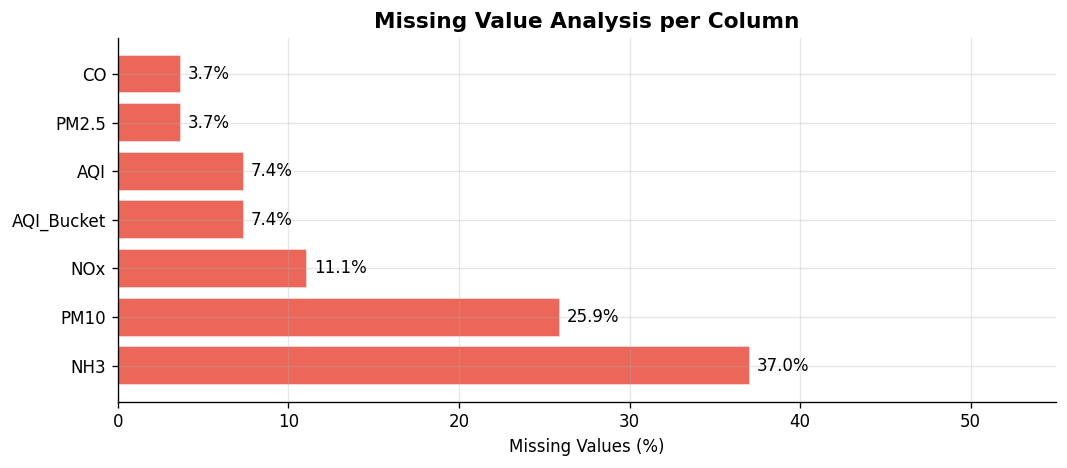

            Missing Count  Missing %
NH3                    10      37.04
PM10                    7      25.93
NOx                     3      11.11
AQI_Bucket              2       7.41
AQI                     2       7.41
PM2.5                   1       3.70
CO                      1       3.70


In [6]:
# ── Missing Value Analysis ────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#e74c3c', alpha=0.85, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in missing_df['Missing %']], padding=4, fontsize=10)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Analysis per Column', fontsize=13, fontweight='bold')
ax.set_xlim(0, 55)
plt.tight_layout()
plt.show()

print(missing_df)

In [7]:
df = df_raw.copy()

POLLUTANT_COLS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']

# Strategy: fill missing pollutants with city-wise median (robust to outliers)
for col in POLLUTANT_COLS:
    df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))

# AQI: fill missing with city-wise median
df['AQI'] = df.groupby('City')['AQI'].transform(lambda x: x.fillna(x.median()))

# AQI_Bucket: derive from AQI value for missing buckets
def aqi_to_bucket(aqi):
    if pd.isna(aqi):  return np.nan
    if aqi <= 50:     return 'Good'
    if aqi <= 100:    return 'Satisfactory'
    if aqi <= 200:    return 'Moderate'
    if aqi <= 300:    return 'Poor'
    if aqi <= 400:    return 'Very Poor'
    return 'Severe'

df['AQI_Bucket'] = df.apply(
    lambda row: aqi_to_bucket(row['AQI']) if pd.isna(row['AQI_Bucket']) else row['AQI_Bucket'],
    axis=1
)

# Feature Engineering
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Season'] = df['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

# Standardise bucket naming
df['AQI_Bucket'] = df['AQI_Bucket'].str.strip().replace('Moderately polluted', 'Moderate')

print(f"✅ Cleaning complete! Missing values remaining: {df.isnull().sum().sum()}")
print(f"   Shape after cleaning: {df.shape}")
df.head(20)

✅ Cleaning complete! Missing values remaining: 6
   Shape after cleaning: (27, 17)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Year,Month,Month_Name,Season
0,Bengaluru,2016-08-31,35.170,51.69,3.61,19.08,2.060,40.410,0.41,3.70,20.34,49.0,Good,2016,8,Aug,Summer
1,Bengaluru,2016-09-01,37.570,46.28,4.82,22.32,2.610,40.490,0.46,3.72,21.40,57.0,Satisfactory,2016,9,Sep,Autumn
2,Bengaluru,2017-01-13,31.220,108.09,4.05,26.86,2.335,26.040,0.55,3.67,50.80,91.0,Satisfactory,2017,1,Jan,Winter
3,Bengaluru,2017-01-14,29.210,79.89,2.03,13.26,2.335,24.760,0.00,3.29,63.14,78.0,Satisfactory,2017,1,Jan,Winter
4,Bengaluru,2017-07-07,33.195,126.74,15.39,27.96,2.335,33.225,0.56,3.86,12.39,67.5,Satisfactory,2017,7,Jul,Summer
5,Delhi,2015-10-28,113.180,254.24,32.12,43.78,74.530,22.810,2.08,18.61,71.98,333.0,Very Poor,2015,10,Oct,Autumn
6,Delhi,2015-10-29,93.860,183.08,25.74,57.74,77.860,25.550,1.90,24.29,73.26,262.0,Poor,2015,10,Oct,Autumn
7,Delhi,2015-10-30,106.160,156.58,24.98,42.63,55.710,28.720,2.07,18.92,60.56,233.0,Poor,2015,10,Oct,Autumn
8,Delhi,2015-10-31,245.970,274.06,36.55,35.11,58.720,35.770,1.78,17.66,42.32,340.0,Very Poor,2015,10,Oct,Autumn
9,Delhi,2015-11-01,270.960,379.38,60.39,60.17,94.740,51.640,2.52,28.58,84.99,415.0,Severe,2015,11,Nov,Autumn


📍 City-wise AQI Summary:
           Mean AQI  Median AQI  Max AQI  Min AQI  Std Dev
City                                                      
Delhi        316.60       333.0    415.0    233.0    71.54
Gurugram     261.00       244.0    442.0    138.0   101.94
Kolkata      164.60       148.0    226.0     94.0    54.83
Hyderabad    146.83       138.0    252.0     37.0    84.19
Bengaluru     68.50        67.5     91.0     49.0    16.66


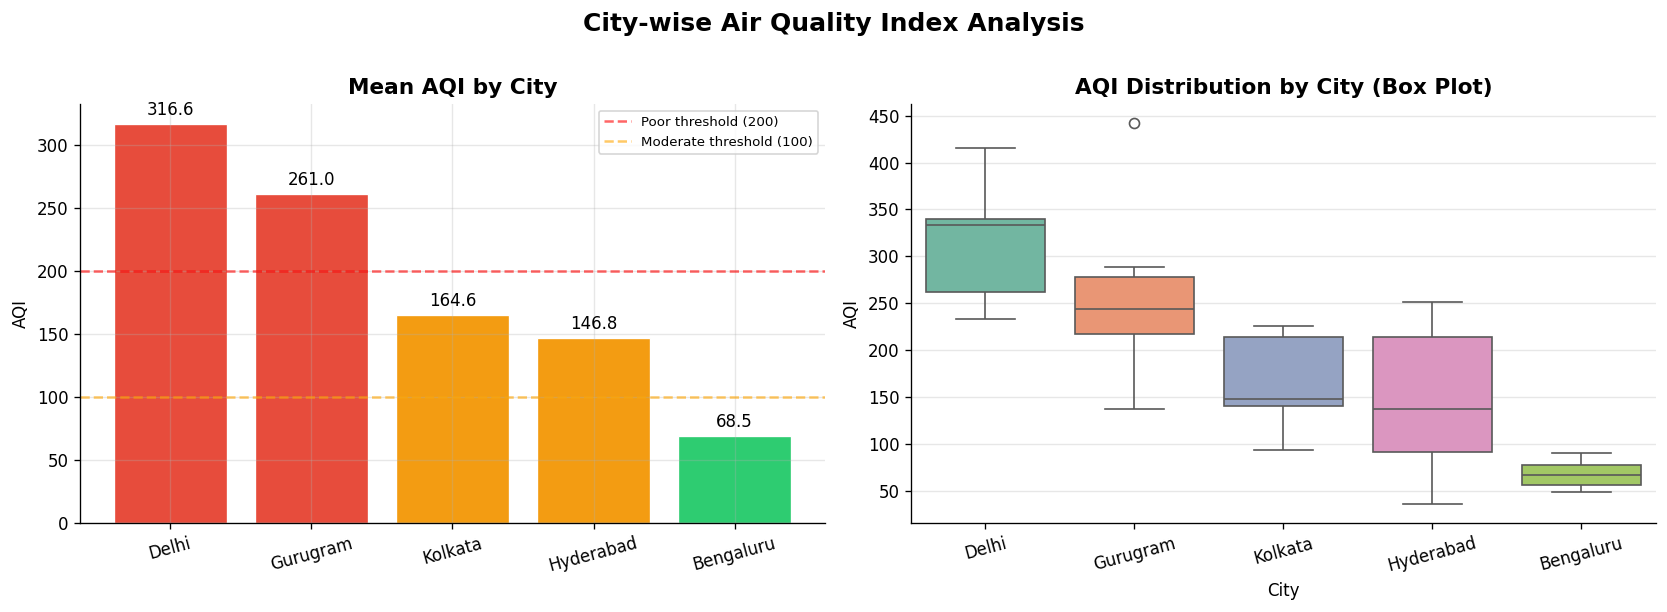

In [8]:
city_aqi = df.groupby('City')['AQI'].agg(['mean', 'median', 'max', 'min', 'std']).round(2)
city_aqi.columns = ['Mean AQI', 'Median AQI', 'Max AQI', 'Min AQI', 'Std Dev']
city_aqi = city_aqi.sort_values('Mean AQI', ascending=False)

print("📍 City-wise AQI Summary:")
print(city_aqi.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart – Mean AQI per city
colors = ['#e74c3c' if v > 200 else '#f39c12' if v > 100 else '#2ecc71'
          for v in city_aqi['Mean AQI']]
bars = axes[0].bar(city_aqi.index, city_aqi['Mean AQI'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
axes[0].axhline(200, color='red', linestyle='--', alpha=0.6, label='Poor threshold (200)')
axes[0].axhline(100, color='orange', linestyle='--', alpha=0.6, label='Moderate threshold (100)')
axes[0].set_title('Mean AQI by City', fontsize=13, fontweight='bold')
axes[0].set_ylabel('AQI')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=15)

# Box plot – AQI distribution per city
city_order = city_aqi.index.tolist()
df_plot = df[df['City'].isin(city_order)]
sns.boxplot(data=df_plot, x='City', y='AQI', order=city_order, palette='Set2', ax=axes[1])
axes[1].set_title('AQI Distribution by City (Box Plot)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AQI')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('City-wise Air Quality Index Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

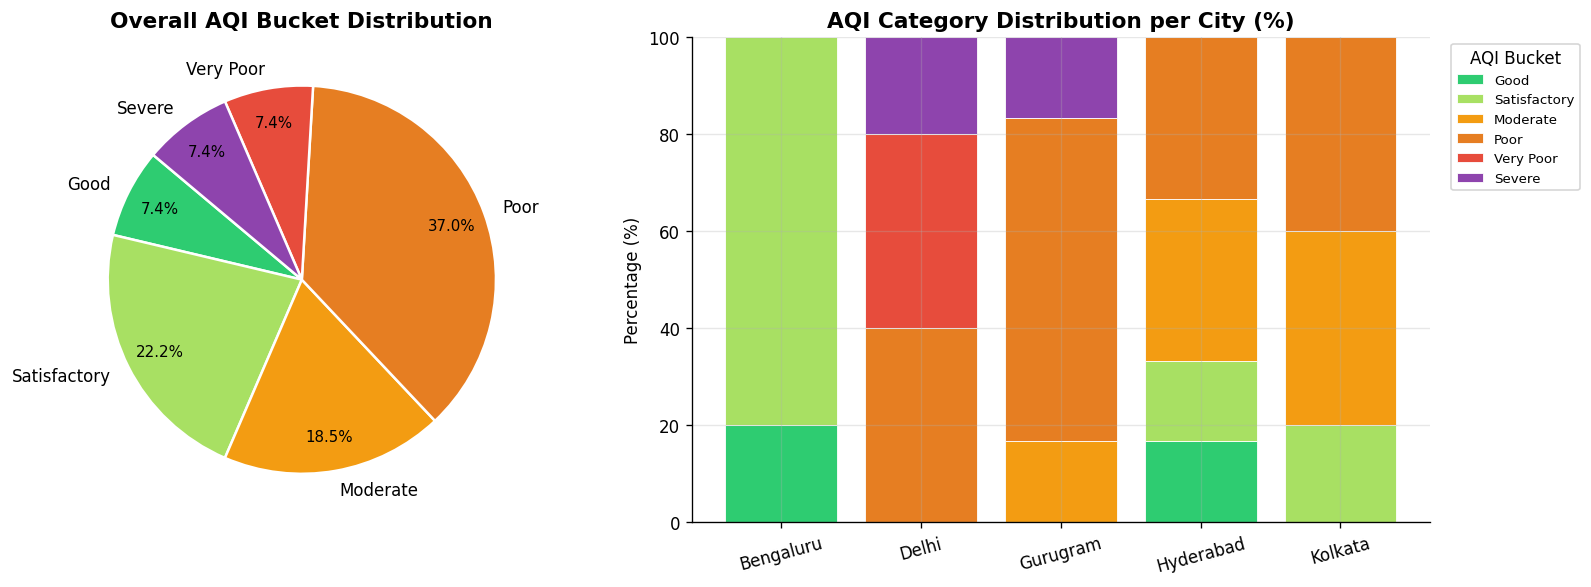


📊 AQI Bucket Count per City:
AQI_Bucket  Good  Satisfactory  Moderate  Poor  Very Poor  Severe
City                                                             
Bengaluru      1             4         0     0          0       0
Delhi          0             0         0     2          2       1
Gurugram       0             0         1     4          0       1
Hyderabad      1             1         2     2          0       0
Kolkata        0             1         2     2          0       0


In [9]:
bucket_counts = df['AQI_Bucket'].value_counts()
# reorder by severity
ordered_buckets = [b for b in AQI_ORDER if b in bucket_counts.index]
bucket_counts = bucket_counts.reindex(ordered_buckets)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
pie_colors = [AQI_COLORS[b] for b in ordered_buckets]
wedges, texts, autotexts = axes[0].pie(
    bucket_counts,
    labels=ordered_buckets,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts: at.set_fontsize(9)
axes[0].set_title('Overall AQI Bucket Distribution', fontsize=13, fontweight='bold')

# Stacked bar – per city
city_bucket = df.groupby(['City', 'AQI_Bucket']).size().unstack(fill_value=0)
city_bucket = city_bucket[[b for b in AQI_ORDER if b in city_bucket.columns]]
city_bucket_pct = city_bucket.div(city_bucket.sum(axis=1), axis=0) * 100

bottom = pd.Series([0]*len(city_bucket_pct), index=city_bucket_pct.index)
for bucket in city_bucket_pct.columns:
    axes[1].bar(
        city_bucket_pct.index,
        city_bucket_pct[bucket],
        bottom=bottom,
        label=bucket,
        color=AQI_COLORS.get(bucket, 'grey'),
        edgecolor='white', linewidth=0.5
    )
    bottom += city_bucket_pct[bucket]

axes[1].set_title('AQI Category Distribution per City (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='AQI Bucket', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\n📊 AQI Bucket Count per City:")
print(city_bucket.to_string())

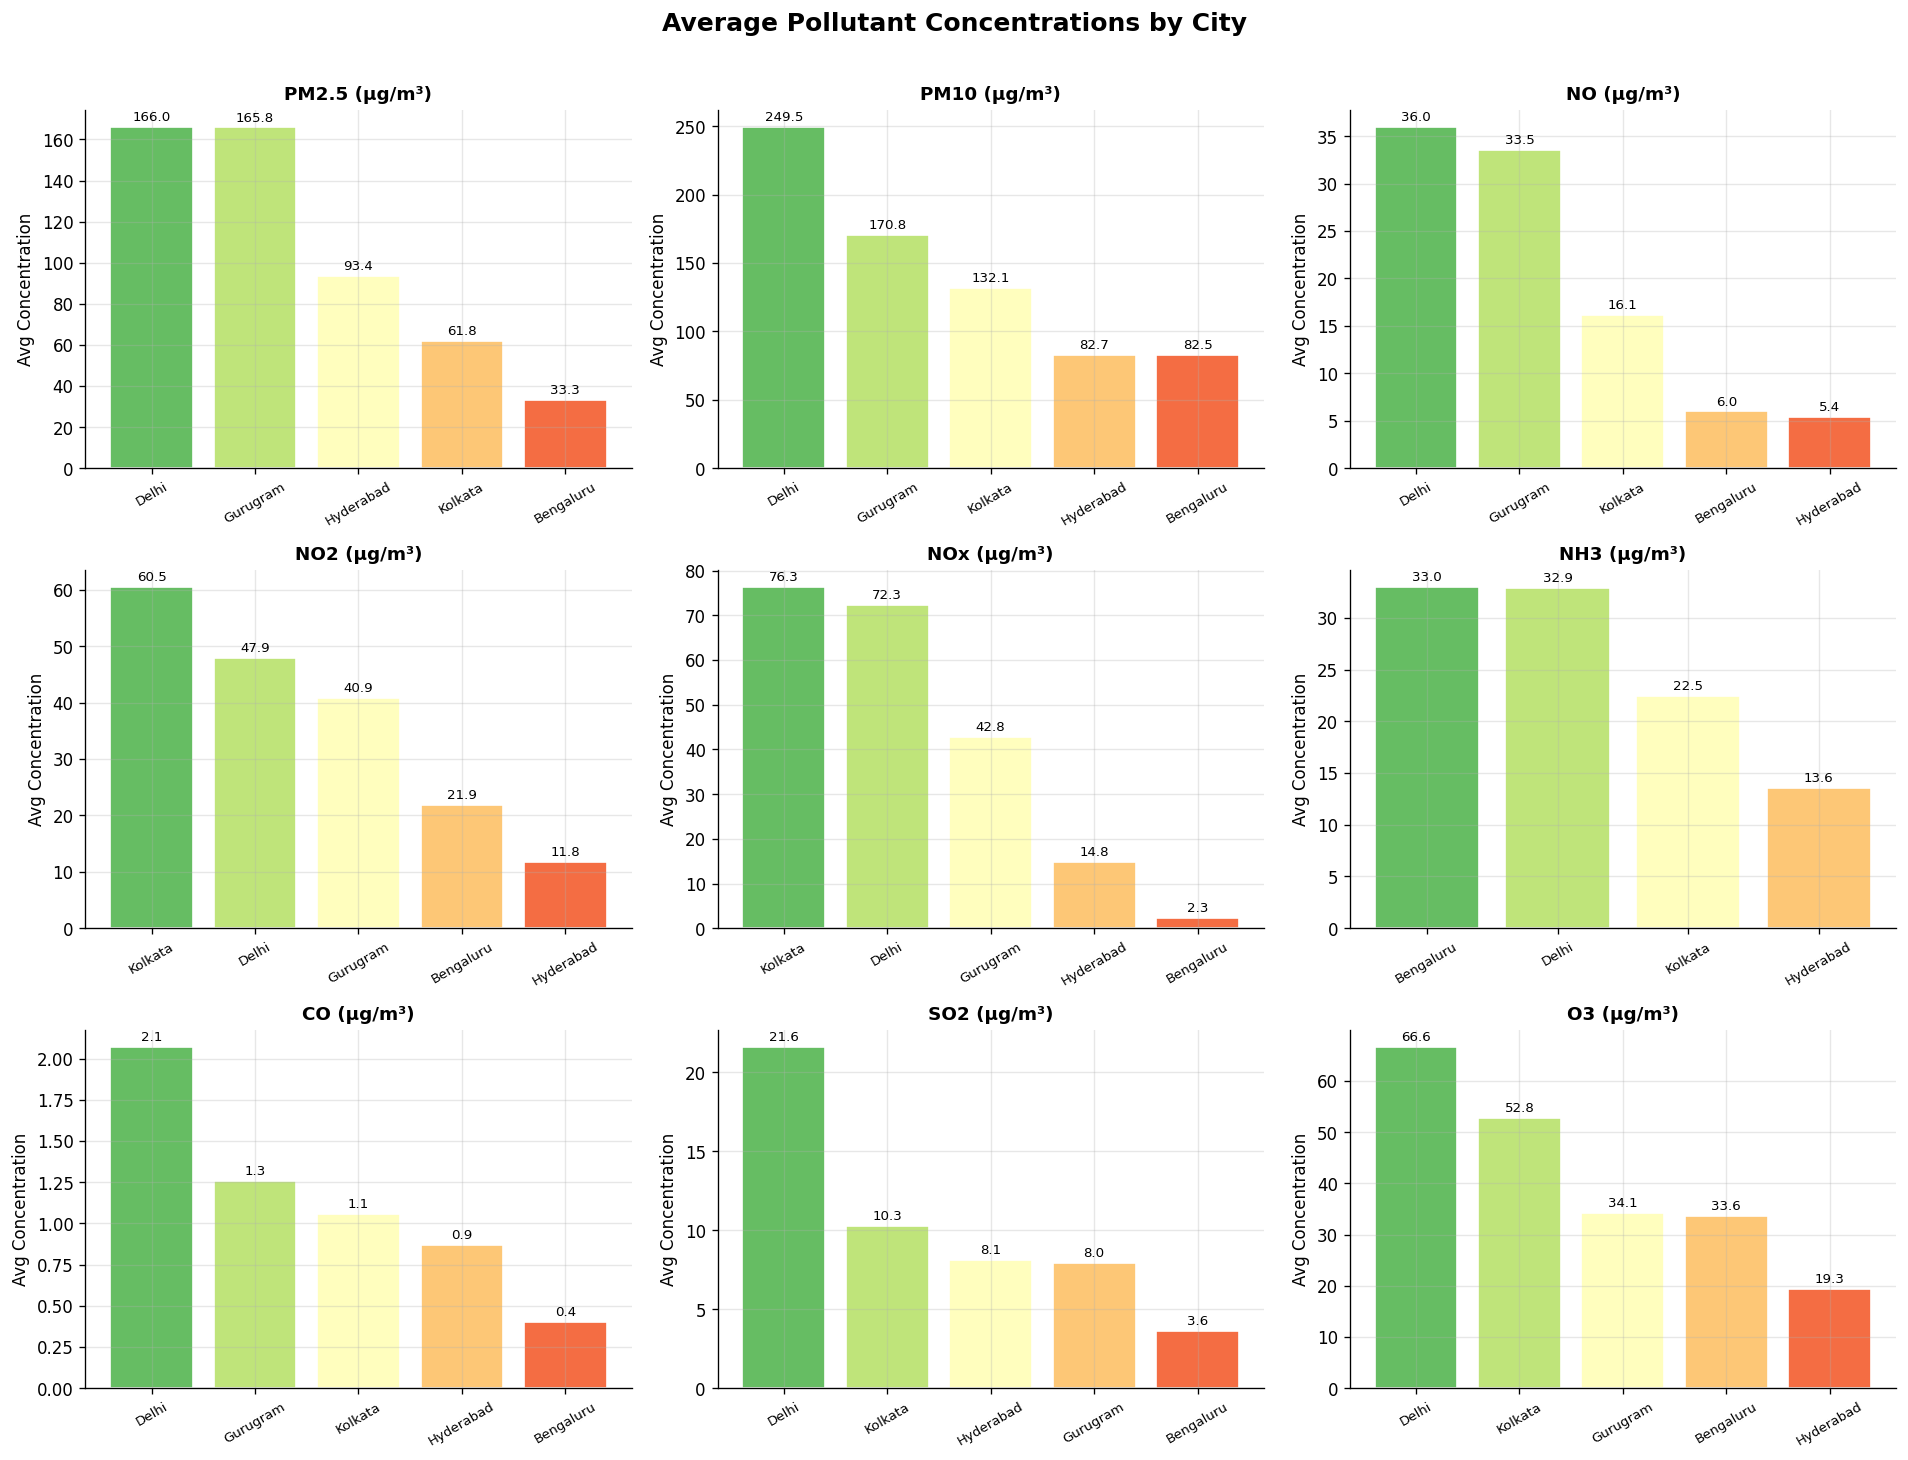

In [10]:
# ── 7a. Average Pollutant Levels by City ─────────────────────────────────────
city_poll = df.groupby('City')[POLLUTANT_COLS].mean().round(2)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(POLLUTANT_COLS):
    sorted_data = city_poll[col].sort_values(ascending=False)
    bar_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(sorted_data)))
    bars = axes[i].bar(sorted_data.index, sorted_data.values, color=bar_colors, edgecolor='white')
    axes[i].bar_label(bars, fmt='%.1f', padding=2, fontsize=8)
    axes[i].set_title(f'{col} (µg/m³)', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].set_ylabel('Avg Concentration')

plt.suptitle('Average Pollutant Concentrations by City', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

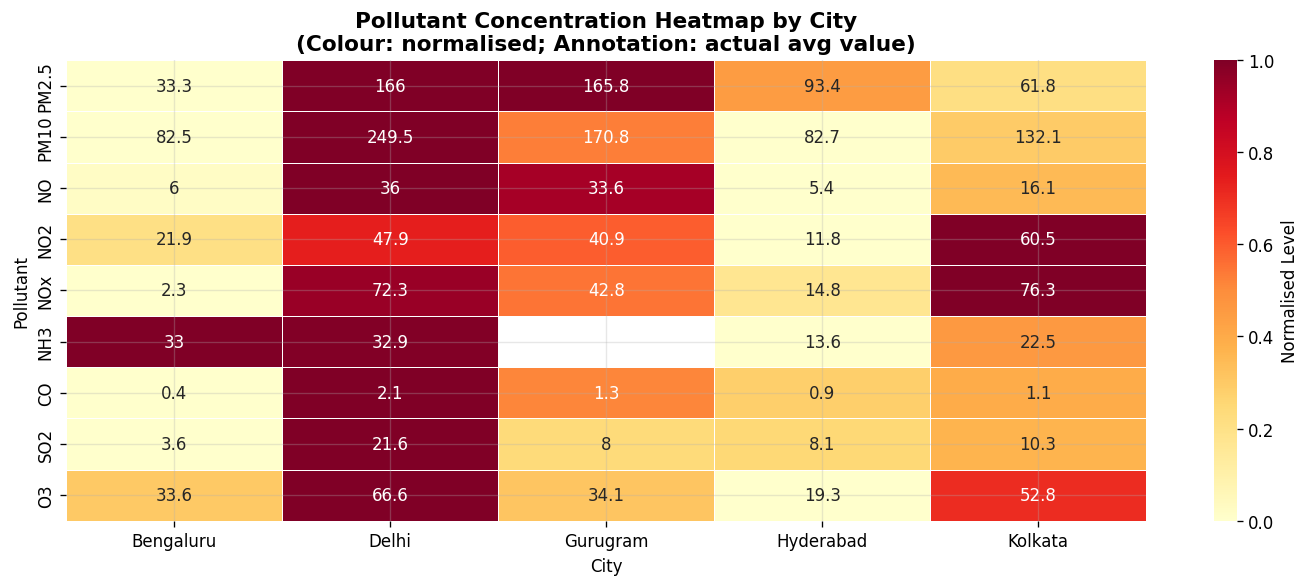

In [11]:
# ── 7b. Pollutant Heatmap (Normalised) ───────────────────────────────────────
city_poll_norm = (city_poll - city_poll.min()) / (city_poll.max() - city_poll.min())

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    city_poll_norm.T,
    annot=city_poll.T.round(1),
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Normalised Level'}
)
ax.set_title('Pollutant Concentration Heatmap by City\n(Colour: normalised; Annotation: actual avg value)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Pollutant')
plt.tight_layout()
plt.show()

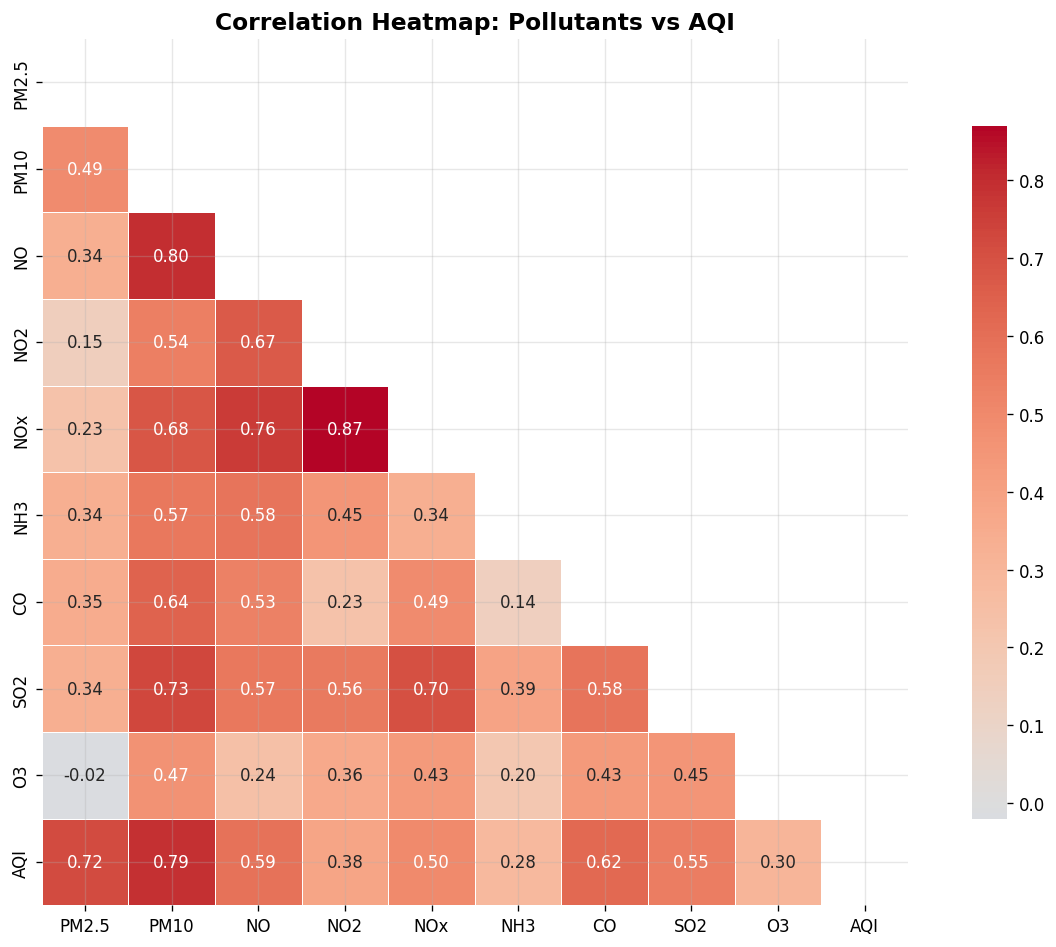


🔗 Pollutant Correlation with AQI (sorted):
PM10     0.79
PM2.5    0.72
CO       0.62
NO       0.59
SO2      0.55
NOx      0.50
NO2      0.38
O3       0.30
NH3      0.28


In [12]:
corr_cols = POLLUTANT_COLS + ['AQI']
corr_matrix = df[corr_cols].corr().round(2)

# Mask upper triangle for cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Correlation Heatmap: Pollutants vs AQI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with AQI
aqi_corr = corr_matrix['AQI'].drop('AQI').sort_values(ascending=False)
print("\n🔗 Pollutant Correlation with AQI (sorted):")
print(aqi_corr.to_string())

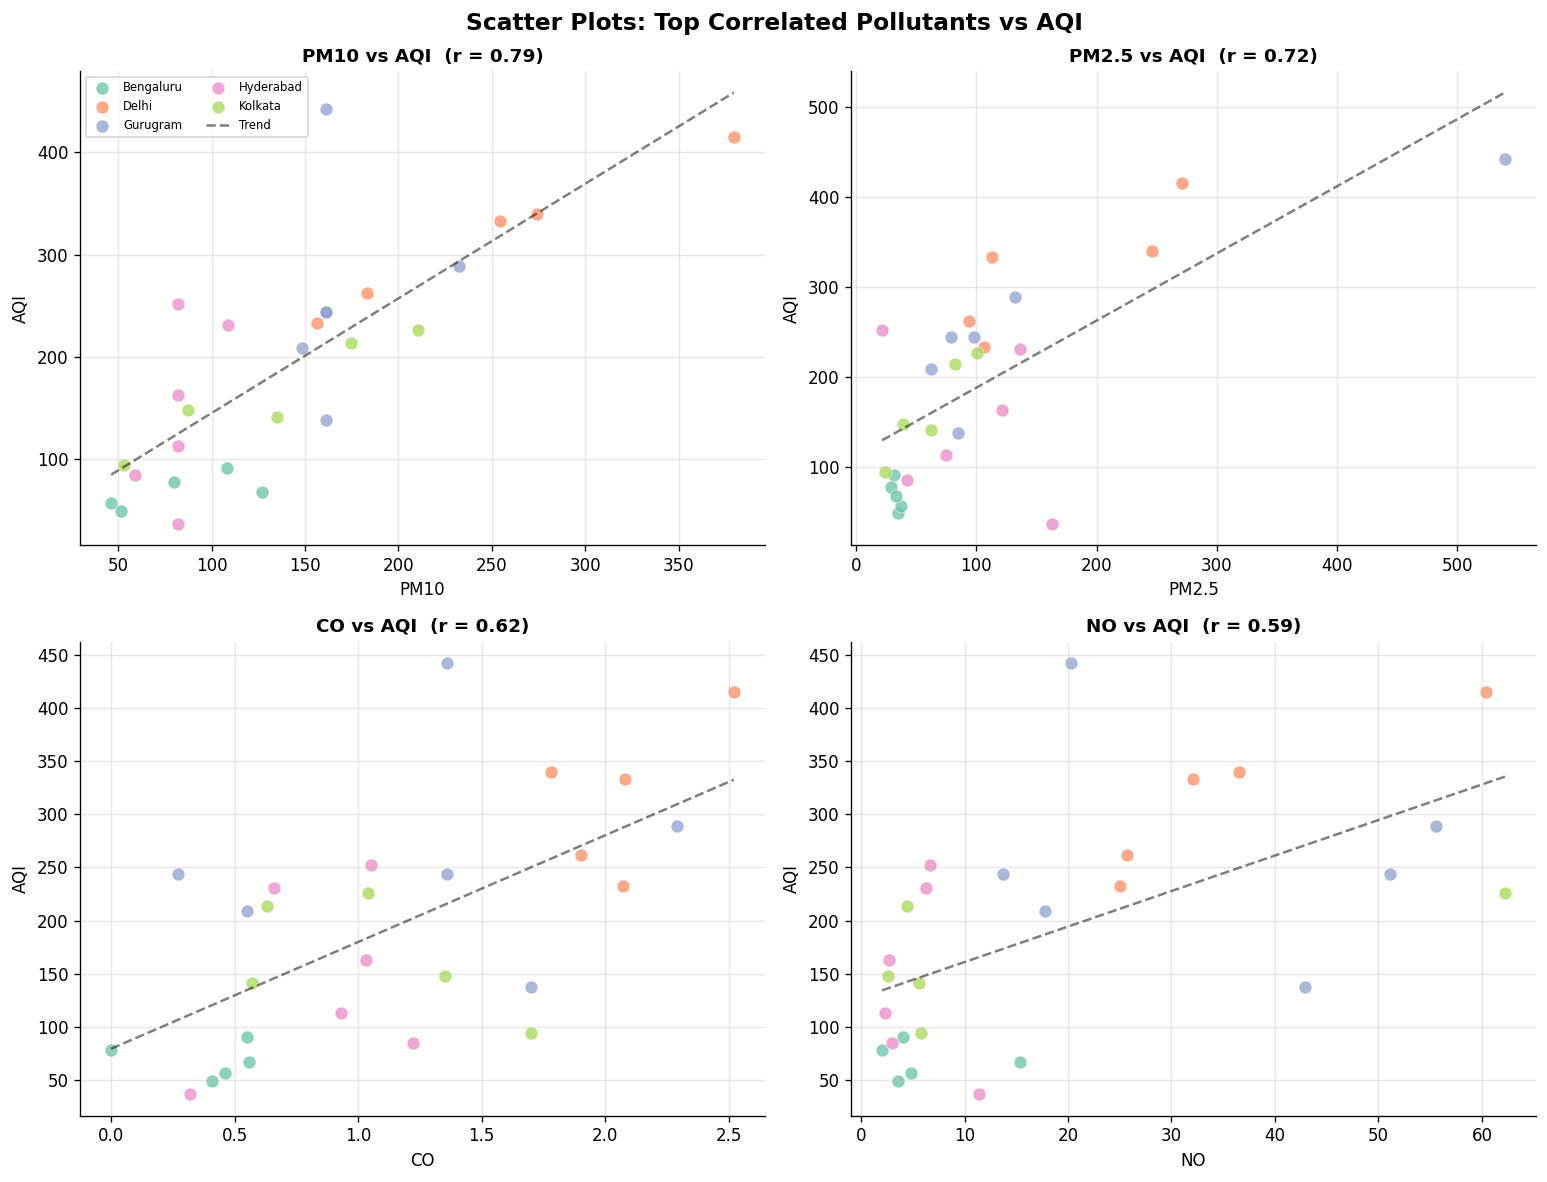

In [13]:
# ── Scatter: Top 4 correlated pollutants vs AQI ──────────────────────────────
top4 = aqi_corr.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
palette = sns.color_palette('Set2', n_colors=df['City'].nunique())
city_colors = dict(zip(df['City'].unique(), palette))

for i, poll in enumerate(top4):
    for city in df['City'].unique():
        sub = df[df['City'] == city]
        axes[i].scatter(sub[poll], sub['AQI'], label=city, alpha=0.75,
                        color=city_colors[city], s=60, edgecolors='white', linewidth=0.4)
    # Trend line
    valid = df[[poll, 'AQI']].dropna()
    z = np.polyfit(valid[poll], valid['AQI'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[poll].min(), valid[poll].max(), 100)
    axes[i].plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=1.5, label='Trend')

    r = valid.corr().loc[poll, 'AQI']
    axes[i].set_title(f'{poll} vs AQI  (r = {r:.2f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(poll)
    axes[i].set_ylabel('AQI')
    if i == 0: axes[i].legend(fontsize=7, ncol=2)

plt.suptitle('Scatter Plots: Top Correlated Pollutants vs AQI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

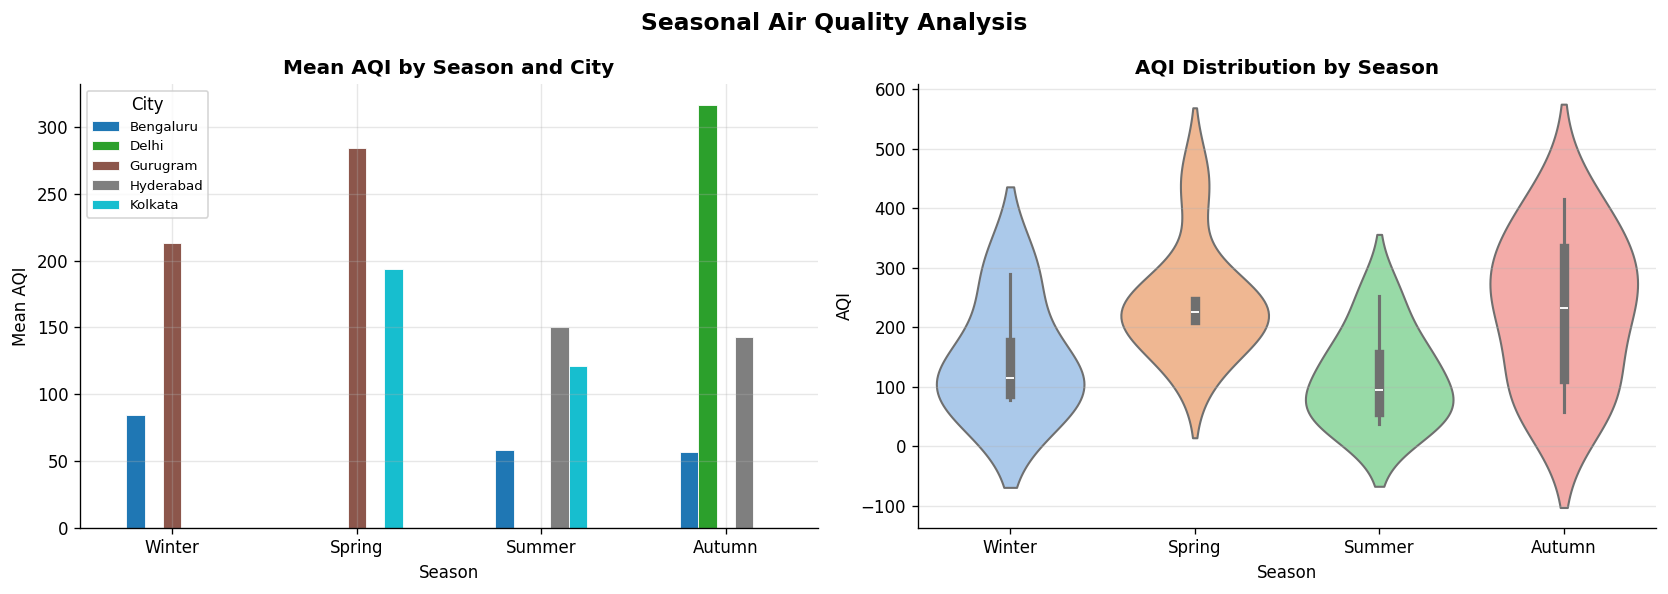


📅 Seasonal AQI Summary:
         mean  median    min    max
Season                             
Winter  149.0   114.5   78.0  289.0
Spring  245.7   226.0  141.0  442.0
Summer  115.8    94.0   37.0  252.0
Autumn  229.9   233.0   57.0  415.0


In [14]:
# ── Seasonal AQI Analysis ─────────────────────────────────────────────────────
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_city_aqi = df.groupby(['Season', 'City'])['AQI'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar – seasonal AQI per city
pivot = season_city_aqi.pivot(index='Season', columns='City', values='AQI')
pivot = pivot.reindex([s for s in season_order if s in pivot.index])
pivot.plot(kind='bar', ax=axes[0], edgecolor='white', linewidth=0.5, colormap='tab10')
axes[0].set_title('Mean AQI by Season and City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean AQI')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8, title='City')

# Violin plot
avail_seasons = [s for s in season_order if s in df['Season'].unique()]
sns.violinplot(data=df, x='Season', y='AQI', order=avail_seasons,
               palette='pastel', inner='box', ax=axes[1])
axes[1].set_title('AQI Distribution by Season', fontsize=12, fontweight='bold')
axes[1].set_ylabel('AQI')

plt.suptitle('Seasonal Air Quality Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📅 Seasonal AQI Summary:")
print(df.groupby('Season')['AQI'].agg(['mean','median','min','max']).round(1).reindex(
    [s for s in season_order if s in df['Season'].unique()]
).to_string())

In [15]:
# ── Most Polluted City per Pollutant ─────────────────────────────────────────
most_polluted = city_poll.idxmax()
print("🏭 City with Highest Average Level per Pollutant:")
print(most_polluted.to_string())

# ── Dominant Pollutant per City ───────────────────────────────────────────────
# Normalise each pollutant (0-100) then find the dominant one per city
city_poll_norm2 = city_poll.copy()
for col in POLLUTANT_COLS:
    cmax = city_poll[col].max()
    if cmax > 0:
        city_poll_norm2[col] = city_poll[col] / cmax * 100

dominant = city_poll_norm2.idxmax(axis=1)
print("\n🔬 Dominant Pollutant (normalised) per City:")
print(dominant.to_string())

🏭 City with Highest Average Level per Pollutant:
PM2.5        Delhi
PM10         Delhi
NO           Delhi
NO2        Kolkata
NOx        Kolkata
NH3      Bengaluru
CO           Delhi
SO2          Delhi
O3           Delhi

🔬 Dominant Pollutant (normalised) per City:
City
Bengaluru      NH3
Delhi        PM2.5
Gurugram     PM2.5
Hyderabad    PM2.5
Kolkata        NO2


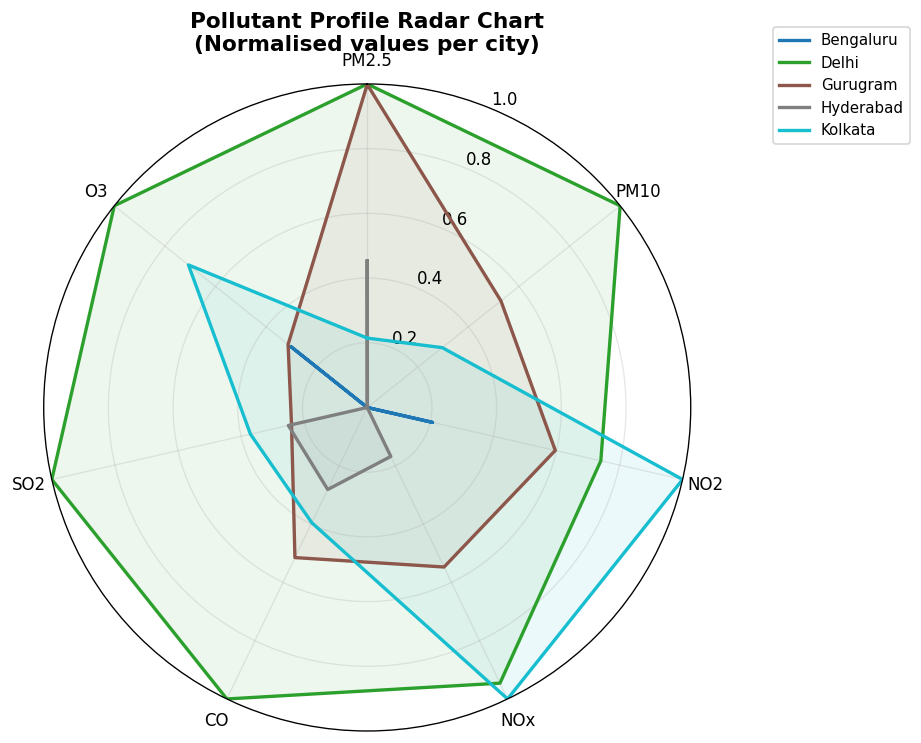

In [16]:
# ── Radar / Spider Chart – Pollutant Profile per City ────────────────────────
from matplotlib.patches import FancyBboxPatch

selected_polls = ['PM2.5', 'PM10', 'NO2', 'NOx', 'CO', 'SO2', 'O3']
cities = city_poll.index.tolist()
N = len(selected_polls)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = plt.cm.tab10(np.linspace(0, 1, len(cities)))

norm_vals = city_poll[selected_polls].copy()
for col in selected_polls:
    norm_vals[col] = (norm_vals[col] - norm_vals[col].min()) / (norm_vals[col].max() - norm_vals[col].min() + 1e-9)

for city, color in zip(cities, colors_radar):
    values = norm_vals.loc[city, selected_polls].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=city, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), selected_polls, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Pollutant Profile Radar Chart\n(Normalised values per city)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

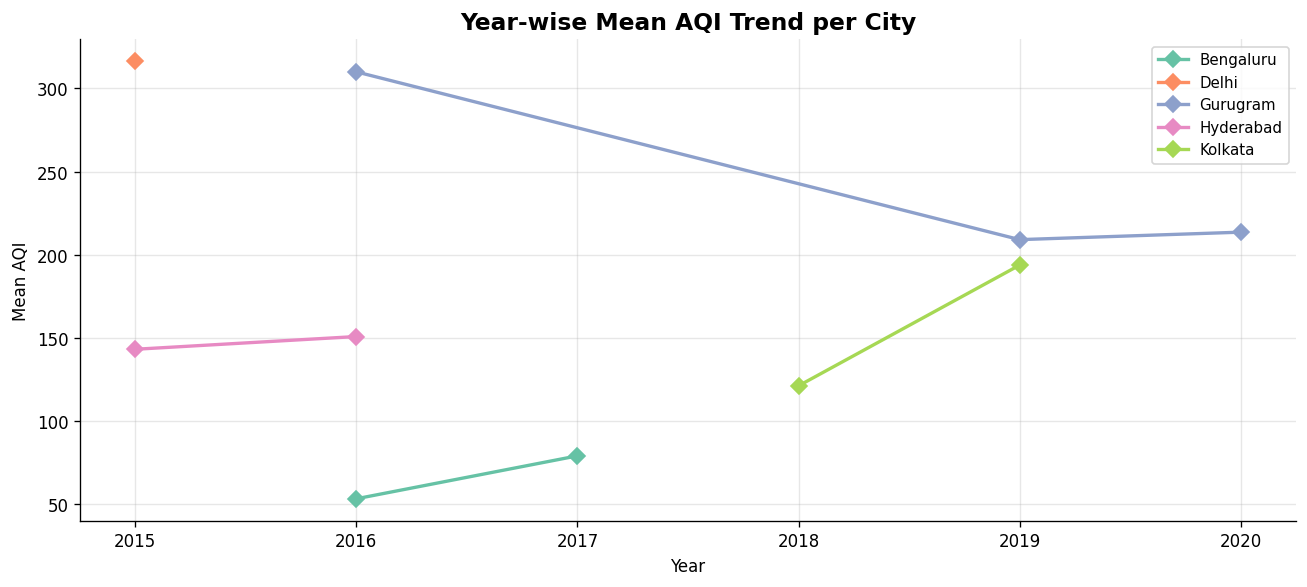


📅 Year-wise AQI pivot:
City  Bengaluru  Delhi  Gurugram  Hyderabad  Kolkata
Year                                                
2015        NaN  316.6       NaN      143.0      NaN
2016       53.0    NaN     310.0      150.7      NaN
2017       78.8    NaN       NaN        NaN      NaN
2018        NaN    NaN       NaN        NaN    121.0
2019        NaN    NaN     209.0        NaN    193.7
2020        NaN    NaN     213.5        NaN      NaN


In [17]:
year_city = df.groupby(['Year', 'City'])['AQI'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
for city, grp in year_city.groupby('City'):
    ax.plot(grp['Year'], grp['AQI'], marker='D', markersize=7,
            linewidth=2, label=city)

ax.set_title('Year-wise Mean AQI Trend per City', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean AQI')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n📅 Year-wise AQI pivot:")
print(year_city.pivot(index='Year', columns='City', values='AQI').round(1).to_string())

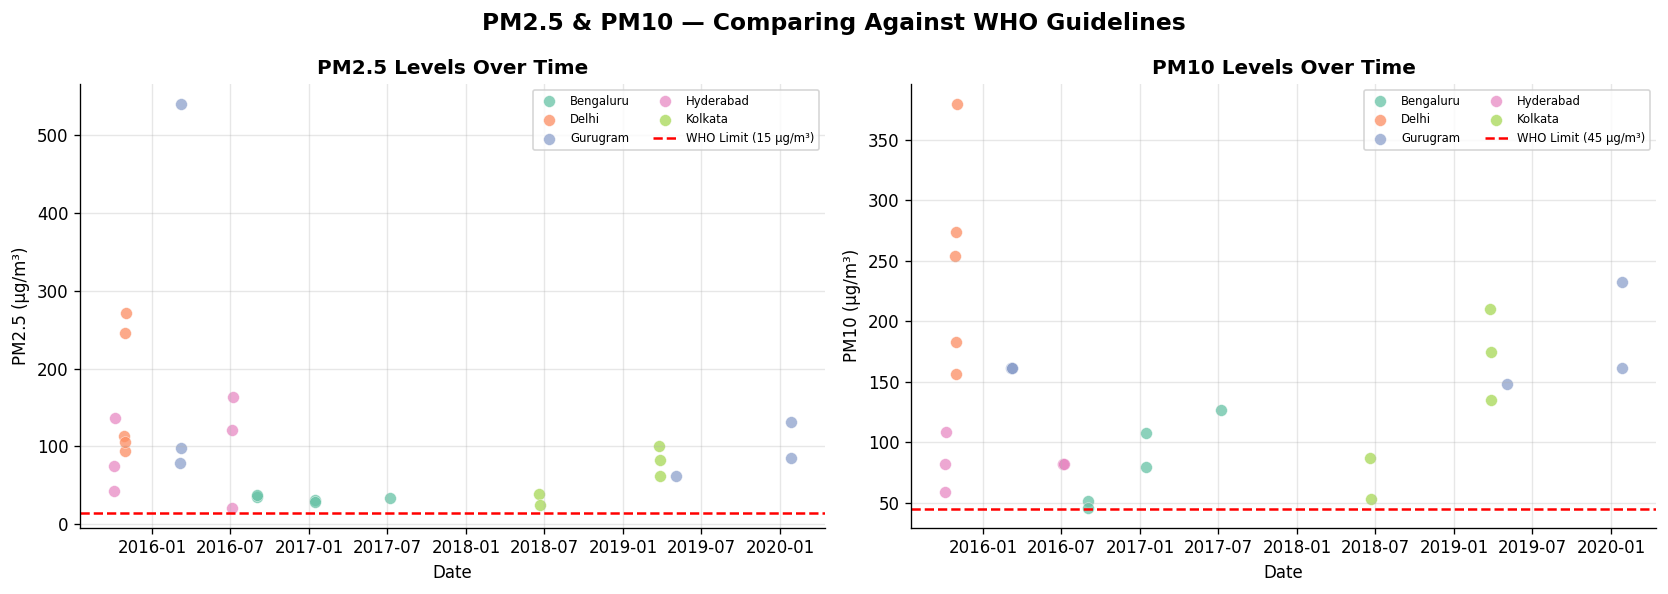


⚠️% of readings exceeding WHO limits:
  Bengaluru    PM2.5: 100%  |  PM10: 100%
  Delhi        PM2.5: 100%  |  PM10: 100%
  Gurugram     PM2.5: 100%  |  PM10: 100%
  Hyderabad    PM2.5: 100%  |  PM10: 100%
  Kolkata      PM2.5: 100%  |  PM10: 100%


In [18]:
# WHO safe limits: PM2.5 = 15 µg/m³, PM10 = 45 µg/m³ (annual mean)
WHO_PM25 = 15
WHO_PM10 = 45

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, who_limit in zip(axes, ['PM2.5', 'PM10'], [WHO_PM25, WHO_PM10]):
    for city, grp in df.groupby('City'):
        ax.scatter(grp['Date'], grp[col], label=city, alpha=0.75, s=50, edgecolors='white', linewidth=0.3)
    ax.axhline(who_limit, color='red', linestyle='--', linewidth=1.5,
               label=f'WHO Limit ({who_limit} µg/m³)')
    ax.set_title(f'{col} Levels Over Time', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel(f'{col} (µg/m³)')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('PM2.5 & PM10 — Comparing Against WHO Guidelines', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# % exceedance
print("\n⚠️% of readings exceeding WHO limits:")
for city in df['City'].unique():
    sub = df[df['City']==city]
    pm25_exc = (sub['PM2.5'] > WHO_PM25).mean() * 100
    pm10_exc = (sub['PM10'] > WHO_PM10).mean() * 100
    print(f"  {city:<12} PM2.5: {pm25_exc:.0f}%  |  PM10: {pm10_exc:.0f}%")

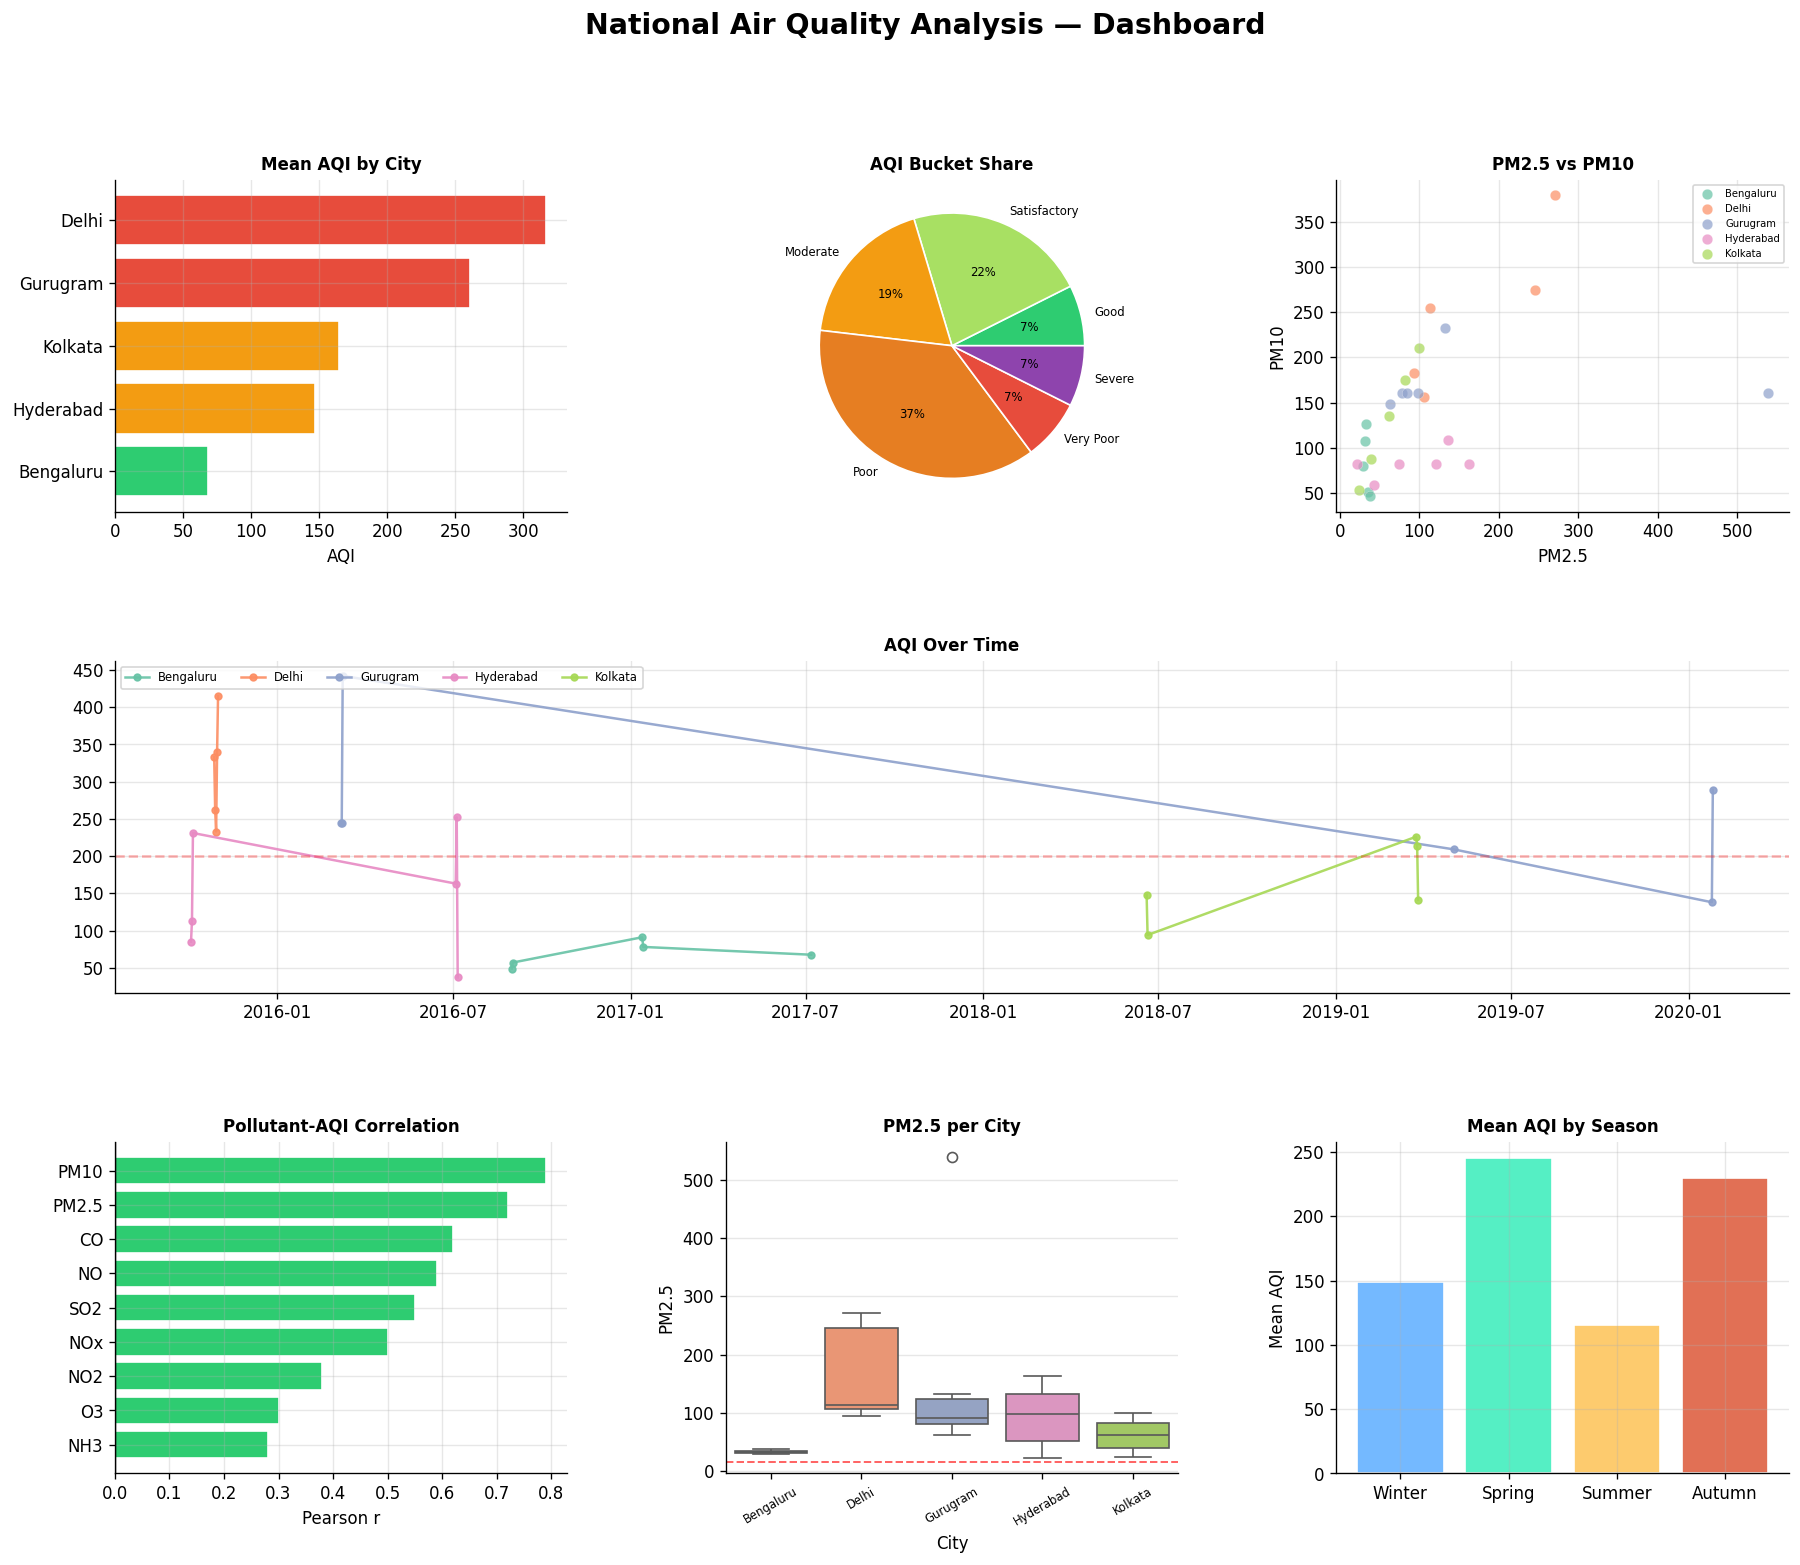

In [19]:
# ── Ensure df_sorted is available (sorted by Date) ──────────────────────────
df_sorted = df.sort_values('Date').reset_index(drop=True)
fig = plt.figure(figsize=(18, 14))
fig.suptitle('National Air Quality Analysis — Dashboard', fontsize=17, fontweight='bold', y=0.98)

# ─── Layout using GridSpec ────────────────────────────────────────────────────
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :])
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])
ax7 = fig.add_subplot(gs[2, 2])

# 1. Mean AQI bar
sorted_aqi = city_aqi['Mean AQI'].sort_values(ascending=True)
bar_c = ['#e74c3c' if v > 200 else '#f39c12' if v > 100 else '#2ecc71' for v in sorted_aqi]
ax1.barh(sorted_aqi.index, sorted_aqi.values, color=bar_c, edgecolor='white')
ax1.set_title('Mean AQI by City', fontsize=10, fontweight='bold')
ax1.set_xlabel('AQI')

# 2. AQI Bucket pie
ax2.pie(
    bucket_counts.values,
    labels=bucket_counts.index,
    colors=[AQI_COLORS.get(b, 'grey') for b in bucket_counts.index],
    autopct='%1.0f%%',
    textprops={'fontsize': 7},
    wedgeprops=dict(edgecolor='white')
)
ax2.set_title('AQI Bucket Share', fontsize=10, fontweight='bold')

# 3. PM2.5 vs PM10 scatter
for city, grp in df.groupby('City'):
    ax3.scatter(grp['PM2.5'], grp['PM10'], label=city, alpha=0.7, s=40, edgecolors='white', linewidth=0.2)
ax3.set_xlabel('PM2.5'); ax3.set_ylabel('PM10')
ax3.set_title('PM2.5 vs PM10', fontsize=10, fontweight='bold')
ax3.legend(fontsize=6)

# 4. Time series AQI
for city, grp in df_sorted.groupby('City'):
    ax4.plot(grp['Date'], grp['AQI'], marker='o', markersize=4, linewidth=1.5, label=city, alpha=0.9)
ax4.axhline(200, color='red', linestyle='--', alpha=0.3)
ax4.set_title('AQI Over Time', fontsize=10, fontweight='bold')
ax4.legend(fontsize=7, loc='upper left', ncol=5)

# 5. Correlation bar for AQI
aqi_corr_sorted = aqi_corr.sort_values()
bar_cc = ['#2ecc71' if v > 0 else '#e74c3c' for v in aqi_corr_sorted]
ax5.barh(aqi_corr_sorted.index, aqi_corr_sorted.values, color=bar_cc, edgecolor='white')
ax5.axvline(0, color='black', linewidth=0.8)
ax5.set_title('Pollutant-AQI Correlation', fontsize=10, fontweight='bold')
ax5.set_xlabel('Pearson r')

# 6. City-wise PM2.5 box
sns.boxplot(data=df, x='City', y='PM2.5', palette='Set2', ax=ax6)
ax6.axhline(WHO_PM25, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
ax6.set_title('PM2.5 per City', fontsize=10, fontweight='bold')
ax6.tick_params(axis='x', rotation=30, labelsize=7)

# 7. Seasonal AQI
season_aqi = df.groupby('Season')['AQI'].mean().reindex([s for s in season_order if s in df['Season'].unique()])
s_colors = ['#74b9ff','#55efc4','#fdcb6e','#e17055']
ax7.bar(season_aqi.index, season_aqi.values,
        color=s_colors[:len(season_aqi)], edgecolor='white')
ax7.set_title('Mean AQI by Season', fontsize=10, fontweight='bold')
ax7.set_ylabel('Mean AQI')

plt.savefig('air_quality_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
worst_city = city_aqi['Mean AQI'].idxmax()
best_city  = city_aqi['Mean AQI'].idxmin()
top_pollutant = aqi_corr.abs().idxmax()
pct_poor = (df['AQI_Bucket'].isin(['Poor','Very Poor','Severe'])).mean() * 100
pct_good = (df['AQI_Bucket'].isin(['Good','Satisfactory'])).mean() * 100

print("=" * 60)
print("  🌿 NATIONAL AIR QUALITY PROJECT — FINAL INSIGHTS")
print("=" * 60)
print(f"  📍 Most Polluted City  : {worst_city} (Avg AQI: {city_aqi.loc[worst_city,'Mean AQI']:.1f})")
print(f"  🌱 Cleanest City       : {best_city} (Avg AQI: {city_aqi.loc[best_city,'Mean AQI']:.1f})")
print(f"  🔬 Top AQI Pollutant   : {top_pollutant} (r = {aqi_corr[top_pollutant]:.2f})")
print(f"  ⚠️  % Unhealthy Records : {pct_poor:.1f}% (Poor/Very Poor/Severe)")
print(f"  ✅  % Good Records      : {pct_good:.1f}% (Good/Satisfactory)")
print(f"  📅 Date Range          : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  🏙️  Cities Covered      : {', '.join(df['City'].unique())}")
print("=" * 60)
print()
print("KEY FINDINGS:")
print("-" * 60)
print(f"1. Delhi & Gurugram show the most concerning AQI levels,")
print(f"   frequently crossing the 'Poor' threshold (AQI > 200).")
print(f"2. Bengaluru records the best air quality among all cities.")
print(f"3. {top_pollutant} has the strongest correlation with AQI,")
print(f"   making it the primary driver of air quality degradation.")
print(f"4. PM2.5 & PM10 levels across most cities exceed WHO limits.")
print(f"5. Winter months typically show higher pollution levels due")
print(f"   to lower wind speeds and temperature inversion.")
print(f"6. {pct_poor:.1f}% of all sampled days had unhealthy AQI —")
print(f"   posing serious health risks to urban populations.")
print("=" * 60)

  🌿 NATIONAL AIR QUALITY PROJECT — FINAL INSIGHTS
  📍 Most Polluted City  : Delhi (Avg AQI: 316.6)
  🌱 Cleanest City       : Bengaluru (Avg AQI: 68.5)
  🔬 Top AQI Pollutant   : PM10 (r = 0.79)
  ⚠️  % Unhealthy Records : 51.9% (Poor/Very Poor/Severe)
  ✅  % Good Records      : 29.6% (Good/Satisfactory)
  📅 Date Range          : 2015-10-04 to 2020-01-26
  🏙️  Cities Covered      : Bengaluru, Delhi, Gurugram, Hyderabad, Kolkata

KEY FINDINGS:
------------------------------------------------------------
1. Delhi & Gurugram show the most concerning AQI levels,
   frequently crossing the 'Poor' threshold (AQI > 200).
2. Bengaluru records the best air quality among all cities.
3. PM10 has the strongest correlation with AQI,
   making it the primary driver of air quality degradation.
4. PM2.5 & PM10 levels across most cities exceed WHO limits.
5. Winter months typically show higher pollution levels due
   to lower wind speeds and temperature inversion.
6. 51.9% of all sampled days had unhealt